# EEG_10 — Advanced GNN per Imagined Speech

**Obiettivo**: Confrontare 4 architetture GNN recenti (2023–2025) che superano i limiti di GCN/GAT statici.
Ogni modello affronta in modo diverso i problemi identificati in EEG_07c/07d:
- grafo pairwise semanticamente piatto
- variabilità inter-soggetto dominante (ε²=0.85)
- spettro del Laplaciano indistinguibile tra categorie

## Modelli

| # | Modello | Idea chiave | Paper |
|---|---------|-------------|-------|
| A | **LGGNet** | Grafo locale (regioni cerebrali) + grafo globale | IEEE TNNLS 2023 |
| B | **DiffPool-GNN** | Pooling differenziabile: raggruppa elettrodi adattativamente | DDGHFNet, IF 2025 |
| C | **CBraMod** | Foundation model pre-trained, fine-tuning cross-subject | ICLR 2025 |
| D | **AT-DGNN** | Attenzione temporale + grafo dinamico appreso | BIBM 2024 |

**Nota**: EEG_11 contiene l'implementazione degli Hypergraph Neural Networks (DHSLP/DHSLF).

---
**Ambiente**: `daniele_311` (Python 3.11, PyTorch 2.5, PyG 2.7, Braindecode 1.3.2)

In [ ]:
# ── Configurazione globale ──────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score
import warnings, math, time, csv, os
warnings.filterwarnings('ignore')

# PyG
from torch_geometric.nn import GCNConv, GATConv, ChebConv
from torch_geometric.utils import to_dense_adj, to_dense_batch

# Trova root progetto
def find_project_root(start):
    p = Path(start).resolve()
    while p != p.parent:
        if (p / '.git').exists(): return p
        p = p.parent
    raise FileNotFoundError('Root non trovata')

ROOT          = find_project_root('.')
GRAPHS_DIR    = ROOT / 'data' / 'interim' / 'graphs'
INTERIM_DIR   = ROOT / 'data' / 'interim'
EEG10_INTERIM = ROOT / 'data' / 'interim' / 'eeg10'   # CSV history / results
EEG10_CKPT    = ROOT / 'models' / 'eeg10'              # checkpoint .pt
FIGURES_DIR   = ROOT / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
EEG10_INTERIM.mkdir(parents=True, exist_ok=True)
EEG10_CKPT.mkdir(parents=True, exist_ok=True)

# ── Iperparametri comuni ────────────────────────────────────────────────────
GRAPH_METHOD  = 'pcc'          # dataset pre-costruito da usare come sorgente dati
K_GRAPH       = 6
CLUSTER_SCHEME = 'concr4'      # 4 classi semantiche
N_CHANS       = 59
N_TIMES       = 384            # campioni per trial (~1.5s @ 256Hz)
BATCH_SIZE    = 64
MAX_EPOCHS    = 80
LR            = 1e-3
PATIENCE      = 15             # early stopping
N_TEST_SUBJ   = 10             # soggetti riservati per test
N_VAL_SUBJ    = 10             # soggetti riservati per validation
SEED          = 42
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(SEED)
np.random.seed(SEED)

import sys
sys.path.insert(0, str(ROOT / 'scripts'))
from utils import load_label_scheme
labelid2cluster, N_CLASSES, cluster_names = load_label_scheme(CLUSTER_SCHEME, INTERIM_DIR)

print(f'Device: {DEVICE}')
print(f'Classi ({N_CLASSES}): {[cluster_names[i] for i in range(N_CLASSES)]}')
print(f'Root: {ROOT}')
print(f'EEG10 interim: {EEG10_INTERIM}')
print(f'EEG10 ckpt:    {EEG10_CKPT}')

## Preprocessing — Caricamento Dati e Split

**Fonte**: dataset pre-costruito `dataset_pcc_k6.pt` (EEG_07b).
Ogni elemento: `Data(x=(59,384), edge_index, y=label_int, subj=subject_id)`.

**Split subject-independent**:
- Soggetti ordinati per ID, ultimi `N_TEST_SUBJ` → test set
- Penultimi `N_VAL_SUBJ` → validation
- Rimanenti → train

Tutti i modelli usano lo stesso split per confronto equo.

In [8]:
# ── Caricamento dataset ─────────────────────────────────────────────────────
pcc_path = GRAPHS_DIR / f'dataset_{GRAPH_METHOD}_k{K_GRAPH}.pt'
if not pcc_path.exists():
    raise FileNotFoundError(f'Dataset non trovato: {pcc_path}\nEsegui prima EEG_07b.')

print('Carico dataset...')
raw_data = torch.load(pcc_path, weights_only=False)
print(f'  Trial totali: {len(raw_data)}')

# Mappa etichette → cluster 0..3
for d in raw_data:
    d.y_cluster = torch.tensor(labelid2cluster[int(d.y.item())], dtype=torch.long)

# Subject-independent split
all_subj = sorted(set(int(d.subj.item()) for d in raw_data))
n_subj   = len(all_subj)
test_subj = set(all_subj[-N_TEST_SUBJ:])
val_subj  = set(all_subj[-(N_TEST_SUBJ + N_VAL_SUBJ):-N_TEST_SUBJ])
train_subj = set(all_subj[:-(N_TEST_SUBJ + N_VAL_SUBJ)])

train_data = [d for d in raw_data if int(d.subj.item()) in train_subj]
val_data   = [d for d in raw_data if int(d.subj.item()) in val_subj]
test_data  = [d for d in raw_data if int(d.subj.item()) in test_subj]

print(f'  Soggetti totali: {n_subj}')
print(f'  Train: {len(train_subj)} sogg, {len(train_data)} trial')
print(f'  Val:   {len(val_subj)} sogg,  {len(val_data)} trial')
print(f'  Test:  {len(test_subj)} sogg,  {len(test_data)} trial')

# Class weights (anti-collapse)
y_train = torch.tensor([int(d.y_cluster.item()) for d in train_data])
counts  = torch.bincount(y_train, minlength=N_CLASSES).float()
class_weights = (counts.sum() / (N_CLASSES * counts)).to(DEVICE)
print(f'  Class weights: {class_weights.cpu().numpy().round(3)}')

Carico dataset...
  Trial totali: 38926
  Soggetti totali: 74
  Train: 54 sogg, 28366 trial
  Val:   10 sogg,  5500 trial
  Test:  10 sogg,  5060 trial
  Class weights: [1.525 1.02  1.31  0.625]


In [ ]:
# ── Dataset e training utilities comuni ────────────────────────────────────

class EEGRawDataset(Dataset):
    """Dataset per modelli che lavorano sul segnale grezzo (batch, C, T)."""
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        d = self.data[idx]
        # Normalizzazione per-trial (instance norm): rimuove firma soggetto
        x = d.x.float()
        x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)
        return x, d.y_cluster


class EEGGraphDataset(Dataset):
    """Dataset per modelli che usano anche edge_index (batch di grafi PyG)."""
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        d = self.data[idx]
        x = d.x.float()
        x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)
        return x, d.edge_index, d.y_cluster


def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            x, y = batch[0].to(device), batch[-1].to(device)
            if train: optimizer.zero_grad()
            out = model(x) if len(batch) == 2 else model(x, batch[1])
            loss = criterion(out, y)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(y)
            all_preds.extend(out.argmax(1).cpu().tolist())
            all_labels.extend(y.cpu().tolist())
    bacc = balanced_accuracy_score(all_labels, all_preds)
    return total_loss / len(all_labels), bacc


def train_model(model, train_ds, val_ds, model_name, use_graph=False):
    """Loop di training comune. Restituisce (best_val_bacc, history)."""
    loader_kw = dict(batch_size=BATCH_SIZE, num_workers=4, pin_memory=True)
    train_loader = DataLoader(train_ds, shuffle=True,  **loader_kw)
    val_loader   = DataLoader(val_ds,   shuffle=False, **loader_kw)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_bacc, best_epoch, patience_cnt = 0.0, 0, 0
    history = []
    ckpt_path = EEG10_CKPT / f'eeg10_{model_name}.pt'  # salva in models/eeg10/

    print(f'\n[{model_name}] Training su {DEVICE}...')
    t0 = time.time()
    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, tr_bacc = run_epoch(model, train_loader, optimizer, criterion, DEVICE, train=True)
        vl_loss, vl_bacc = run_epoch(model, val_loader,   optimizer, criterion, DEVICE, train=False)
        scheduler.step()
        history.append({'epoch': epoch, 'tr_loss': tr_loss, 'tr_bacc': tr_bacc,
                        'vl_loss': vl_loss, 'vl_bacc': vl_bacc})
        if vl_bacc > best_bacc:
            best_bacc, best_epoch = vl_bacc, epoch
            torch.save(model.state_dict(), ckpt_path)
            patience_cnt = 0
        else:
            patience_cnt += 1
        if epoch % 10 == 0:
            print(f'  ep {epoch:3d} | tr_bacc={tr_bacc:.4f} | vl_bacc={vl_bacc:.4f} | best={best_bacc:.4f} (ep{best_epoch})')
        if patience_cnt >= PATIENCE:
            print(f'  Early stopping ep {epoch}')
            break

    elapsed = time.time() - t0
    print(f'  Completato in {elapsed/60:.1f} min | best val_bacc = {best_bacc:.4f} (ep {best_epoch})')
    return best_bacc, pd.DataFrame(history), str(ckpt_path)


# Dizionario risultati globale
RESULTS = {}
print('Utilities caricate.')

---
## Modello A — LGGNet (Local-Global Graph Network)

**Paper**: Ding et al., *"LGGNet: Learning From Local-Global-Graph Representations for Brain–Computer Interface"*,
IEEE TNNLS 2023. [GitHub](https://github.com/yi-ding-cs/LGG)

**Idea chiave**: invece di trattare i 59 elettrodi come un unico grafo,
LGGNet li raggruppa prima per **regione cerebrale** (grafo locale) e poi
costruisce un **grafo globale** tra le regioni.

```
Input (B, 59, 384)
    ↓  Conv temporale multi-scala per elettrodo
(B, 59, F_temp)
    ↓  Grafo locale: GCN dentro ogni regione (7 regioni)
(B, 7, F_local)   ← un vettore per regione
    ↓  Grafo globale: GAT tra le 7 regioni
(B, 7, F_global)
    ↓  Flatten + FC
(B, 4)            ← logits 4 categorie
```

**Perché potrebbe funzionare meglio di GCN**: aggrega informazione a livello di regione
(non di singolo elettrodo) → riduce rumore per-elettrodo e cattura pattern
a scala più coarse. Le 7 regioni corrispondono ad aree funzionali del linguaggio.

**Regioni cerebrali usate** (standard 10-20):
- Prefrontale (Fp/AF), Frontale (F), Frontocentrale (FC), Centrale (C/T),
  Centroparietale (CP/TP), Parietale (P), Occipitale (PO/O)

In [10]:
# ── LGGNet — Definizione regioni cerebrali ──────────────────────────────────
import math as _math

# Carica nomi canali nello stesso ordine usato in EEG_07c
def read_eloc(path):
    pos = {}
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 4:
                try:
                    th = _math.radians(float(parts[1]))
                    r  = float(parts[2])
                    nm = parts[3]
                    if nm not in ('A1', 'A2'):
                        pos[nm] = (r * _math.sin(th), r * _math.cos(th))
                except: pass
    return pos

eloc     = read_eloc(ROOT / 'src' / 'io' / 'ebneuro.locs')
CH_NAMES = [n for n in eloc if n not in ('A1', 'A2')][:N_CHANS]
ch2idx   = {n: i for i, n in enumerate(CH_NAMES)}

# Assegna ogni elettrodo a una regione in base al prefisso del nome
def assign_region(name):
    n = name.upper()
    if n.startswith(('FP', 'AF')):         return 'prefrontal'
    if n.startswith('F') and 'C' not in n: return 'frontal'
    if n.startswith('FC') or n.startswith('FT'): return 'frontocentral'
    if n.startswith('C') or n.startswith('T'):   return 'central'
    if n.startswith('CP') or n.startswith('TP'): return 'centroparietal'
    if n.startswith('P') and 'O' not in n:       return 'parietal'
    return 'occipital'  # PO, O

region_names = ['prefrontal', 'frontal', 'frontocentral', 'central',
                'centroparietal', 'parietal', 'occipital']
N_REGIONS    = len(region_names)

region_indices = {r: [] for r in region_names}
for name in CH_NAMES:
    region_indices[assign_region(name)].append(ch2idx[name])

for r, idxs in region_indices.items():
    print(f'  {r:18s}: {len(idxs):2d} ch — {[CH_NAMES[i] for i in idxs]}')

  prefrontal        :  8 ch — ['AF7', 'AF3', 'Fp1', 'FP2', 'AF4', 'AF8', 'FPz', 'AFz']
  frontal           : 11 ch — ['F7', 'F5', 'F3', 'F1', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FT8', 'Fz']
  frontocentral     :  7 ch — ['FC5', 'FC3', 'FC1', 'FC2', 'FC4', 'FC6', 'FCz']
  central           : 20 ch — ['T3', 'C5', 'C3', 'C1', 'C2', 'C4', 'C6', 'T4', 'TP7', 'CP5', 'CP3', 'CP1', 'CP2', 'CP4', 'CP6', 'TP8', 'T5', 'T6', 'Cz', 'CPz']
  centroparietal    :  0 ch — []
  parietal          :  6 ch — ['P5', 'P3', 'P1', 'P2', 'P4', 'P6']
  occipital         :  7 ch — ['PO7', 'PO3', 'O1', 'O2', 'PO4', 'PO8', 'Oz']


In [11]:
# ── LGGNet — Architettura ───────────────────────────────────────────────────

class LocalGraphConv(nn.Module):
    """GCN con adiacenza appresa dentro una regione cerebrale."""
    def __init__(self, in_features, out_features, n_nodes):
        super().__init__()
        self.W   = nn.Linear(in_features, out_features, bias=False)
        # adiacenza appresa (n_nodes × n_nodes), resa simmetrica
        self.adj = nn.Parameter(torch.eye(n_nodes) + 0.1 * torch.randn(n_nodes, n_nodes))
        self.bn  = nn.BatchNorm1d(out_features)
        self.act = nn.ELU()

    def forward(self, x):
        # x: (B, n_nodes, in_features)
        A = F.softmax(self.adj + self.adj.T, dim=-1)  # simmetrica
        x = torch.bmm(A.unsqueeze(0).expand(x.size(0), -1, -1), x)  # (B, n_nodes, in)
        x = self.W(x)                                                  # (B, n_nodes, out)
        # BN su dim features
        b, n, f = x.shape
        x = self.bn(x.reshape(b * n, f)).reshape(b, n, f)
        return self.act(x)


class LGGNet(nn.Module):
    def __init__(self, n_classes, n_chans=59, n_times=384,
                 temp_kernels=(25, 51, 101), temp_out=32, local_out=64, global_out=64):
        super().__init__()
        self.region_indices = region_indices
        self.region_names   = region_names

        # 1. Conv temporale multi-scala per elettrodo
        self.temporal_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(1, temp_out, k, padding=k//2),
                nn.BatchNorm1d(temp_out),
                nn.ELU(),
                nn.AdaptiveAvgPool1d(1),
            ) for k in temp_kernels
        ])
        temp_total = temp_out * len(temp_kernels)  # features per elettrodo

        # 2. Grafo locale per regione
        self.local_gcn = nn.ModuleDict({
            r: LocalGraphConv(temp_total, local_out, len(idxs))
            for r, idxs in region_indices.items() if idxs
        })

        # 3. Grafo globale tra regioni (attenzione)
        self.global_attn = nn.MultiheadAttention(local_out, num_heads=4, batch_first=True)
        self.global_bn   = nn.LayerNorm(local_out)

        # 4. Classificatore
        active_regions = [r for r in region_names if region_indices[r]]
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(len(active_regions) * local_out, 128),
            nn.ELU(),
            nn.Dropout(0.5),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        # x: (B, 59, 384)
        B = x.size(0)

        # Estrazione features temporali per ogni elettrodo
        all_feats = []
        for ch_i in range(N_CHANS):
            ch_signal = x[:, ch_i:ch_i+1, :]  # (B, 1, T)
            scales = [conv(ch_signal) for conv in self.temporal_convs]
            feat = torch.cat([s.flatten(1) for s in scales], dim=1)  # (B, temp_total)
            all_feats.append(feat)
        X_elec = torch.stack(all_feats, dim=1)  # (B, 59, temp_total)

        # Grafo locale per regione
        region_reps = []
        for r in self.region_names:
            idxs = self.region_indices[r]
            if not idxs: continue
            x_reg = X_elec[:, idxs, :]           # (B, n_reg, temp_total)
            x_reg = self.local_gcn[r](x_reg)     # (B, n_reg, local_out)
            region_reps.append(x_reg.mean(dim=1)) # (B, local_out) — pooling

        X_global = torch.stack(region_reps, dim=1)  # (B, N_REGIONS, local_out)

        # Grafo globale
        attn_out, _ = self.global_attn(X_global, X_global, X_global)
        X_global = self.global_bn(X_global + attn_out)

        return self.classifier(X_global)


# Test forward
_m = LGGNet(N_CLASSES).to(DEVICE)
_x = torch.randn(4, N_CHANS, N_TIMES).to(DEVICE)
print(f'LGGNet output: {_m(_x).shape}')  # atteso (4, 4)
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Parametri: {n_params:,}')
del _m, _x

LGGNet output: torch.Size([4, 4])
Parametri: 110,867


In [ ]:
# ── LGGNet — Training ───────────────────────────────────────────────────────
model_A = LGGNet(N_CLASSES).to(DEVICE)
ds_train_A = EEGRawDataset(train_data)
ds_val_A   = EEGRawDataset(val_data)

best_bacc_A, history_A, ckpt_A = train_model(model_A, ds_train_A, ds_val_A, 'lggnet')
RESULTS['LGGNet'] = best_bacc_A
history_A.to_csv(EEG10_INTERIM / 'eeg10_lggnet_history.csv', index=False)
print(f'\n[LGGNet] Best val_bacc: {best_bacc_A:.4f}')

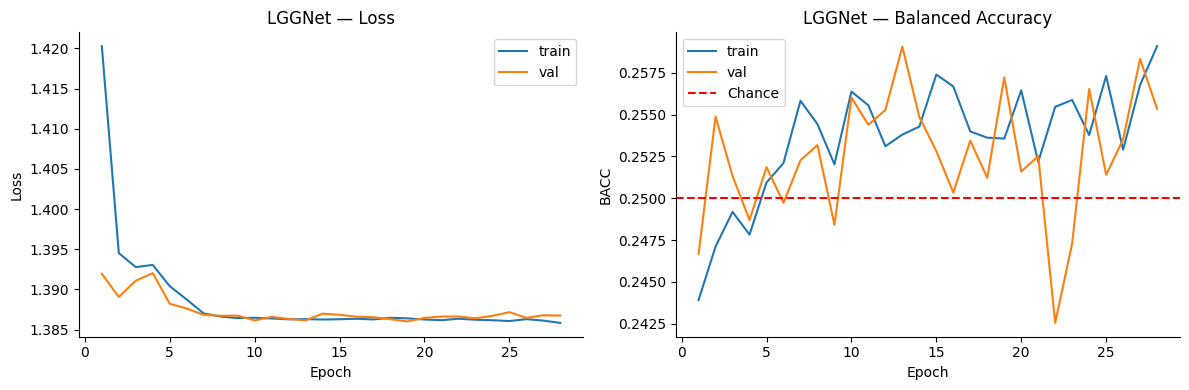

In [13]:
# ── LGGNet — Curva di training ──────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_A['epoch'], history_A['tr_loss'], label='train')
ax1.plot(history_A['epoch'], history_A['vl_loss'], label='val')
ax1.set(title='LGGNet — Loss', xlabel='Epoch', ylabel='Loss')
ax1.legend(); ax1.spines[['top','right']].set_visible(False)
ax2.plot(history_A['epoch'], history_A['tr_bacc'], label='train')
ax2.plot(history_A['epoch'], history_A['vl_bacc'], label='val')
ax2.axhline(0.25, color='red', linestyle='--', label='Chance')
ax2.set(title='LGGNet — Balanced Accuracy', xlabel='Epoch', ylabel='BACC')
ax2.legend(); ax2.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eeg10_lggnet_training.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── LGGNet — Pulizia GPU ──────────────────────────────────────────────────
del model_A, ds_train_A, ds_val_A
import gc; gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated, {torch.cuda.memory_reserved()/1e9:.2f} GB reserved")


---
## Modello B — DiffPool-GNN (DDGHFNet-inspired)

**Paper ispirazione**: Zhang et al., *"Decoding multilingual imagined speech from scalp EEG
via dynamic differentiable graph hierarchical fusion network"*, *Information Fusion* 2025.

**Idea chiave**: usare **DiffPool** (Ying et al., NeurIPS 2018) per raggruppare
adattativamente gli elettrodi in cluster funzionali appresi dai dati, invece di
usare regioni fisse (LGGNet) o grafi pairwise (GCN).

```
Input (B, 59, 384)
    ↓  Multi-scale temporal conv → node features
(B, 59, F)
    ↓  Dynamic adjacency (appresa)
    ↓  DiffPool: 59 → K1=20 cluster
(B, 20, F')
    ↓  GCN su cluster
    ↓  DiffPool: 20 → K2=5 cluster
(B, 5, F'')
    ↓  Global mean + FC
(B, 4)
```

**Perché potrebbe funzionare**: DiffPool è differenziabile end-to-end —
i cluster vengono appresi direttamente dall'obiettivo di classificazione.
Non serve decidere a priori quali elettrodi raggruppare.
È il ponte conceptuale tra GCN (grafo pairwise) e HGNN (iperedge di gruppo).

In [14]:
# ── DiffPool-GNN — Architettura ─────────────────────────────────────────────
from torch_geometric.nn import dense_diff_pool

class DenseGCN(nn.Module):
    """GCN per adiacenza densa (batch, N, N)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.lin = nn.Linear(in_ch, out_ch)
        self.bn  = nn.BatchNorm1d(out_ch)

    def forward(self, x, adj):
        # x: (B, N, in_ch) | adj: (B, N, N)
        out = torch.bmm(adj, x)          # aggrega vicini
        out = self.lin(out)               # trasformazione lineare
        b, n, f = out.shape
        out = self.bn(out.reshape(b*n, f)).reshape(b, n, f)
        return F.elu(out)


class DiffPoolGNN(nn.Module):
    def __init__(self, n_classes, n_chans=59, n_times=384,
                 node_feat=64, k1=20, k2=5):
        super().__init__()
        self.k1 = k1
        self.k2 = k2

        # 1. Estrazione features temporali per nodo
        self.temporal = nn.Sequential(
            nn.Conv1d(n_chans, node_feat, kernel_size=25, padding=12),
            nn.BatchNorm1d(node_feat), nn.ELU(),
            nn.Conv1d(node_feat, node_feat, kernel_size=51, padding=25, groups=node_feat),
            nn.BatchNorm1d(node_feat), nn.ELU(),
            nn.AdaptiveAvgPool1d(1),   # (B, node_feat, 1)
        )
        # Reshape → (B, n_chans, node_feat) via per-channel conv
        self.node_embed = nn.Sequential(
            nn.Conv1d(1, node_feat, kernel_size=n_times // 8, padding=n_times // 16),
            nn.BatchNorm1d(node_feat), nn.ELU(),
            nn.AdaptiveAvgPool1d(node_feat),
        )

        # 2. Adiacenza dinamica appresa
        self.adj_mlp = nn.Linear(node_feat, node_feat)

        # 3. GCN livello 1
        self.gcn1_embed = DenseGCN(node_feat, node_feat)
        self.gcn1_pool  = nn.Linear(node_feat, k1)  # assegnamento soft nodi → k1 cluster

        # 4. GCN livello 2
        self.gcn2_embed = DenseGCN(node_feat, node_feat * 2)
        self.gcn2_pool  = nn.Linear(node_feat * 2, k2)

        # 5. Classificatore
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(k2 * node_feat * 2, 128),
            nn.ELU(), nn.Dropout(0.5),
            nn.Linear(128, n_classes)
        )

    def _make_adj(self, x):
        # x: (B, N, F) → A: (B, N, N) normalizzata
        q = self.adj_mlp(x)  # (B, N, F)
        A = torch.bmm(q, q.transpose(1, 2)) / (q.size(-1) ** 0.5)
        return F.softmax(A, dim=-1)

    def forward(self, x):
        # x: (B, 59, 384)
        B = x.size(0)

        # Features per nodo: per ogni canale applica conv temporale
        node_feats = []
        for ch in range(N_CHANS):
            f = self.node_embed(x[:, ch:ch+1, :])  # (B, node_feat, node_feat)
            node_feats.append(f.mean(dim=-1))        # (B, node_feat)
        H = torch.stack(node_feats, dim=1)           # (B, N_CHANS, node_feat)

        # Adiacenza dinamica
        A = self._make_adj(H)                        # (B, N_CHANS, N_CHANS)

        # Livello 1: GCN + DiffPool
        H = self.gcn1_embed(H, A)                    # (B, N_CHANS, node_feat)
        S = F.softmax(self.gcn1_pool(H), dim=-1)     # (B, N_CHANS, k1) assegnamenti
        H, A, _, _ = dense_diff_pool(H, A, S)        # (B, k1, node_feat)

        # Livello 2: GCN + DiffPool
        H = self.gcn2_embed(H, A)                    # (B, k1, node_feat*2)
        S = F.softmax(self.gcn2_pool(H), dim=-1)     # (B, k1, k2)
        H, A, _, _ = dense_diff_pool(H, A, S)        # (B, k2, node_feat*2)

        return self.classifier(H)


_m = DiffPoolGNN(N_CLASSES).to(DEVICE)
_x = torch.randn(4, N_CHANS, N_TIMES).to(DEVICE)
print(f'DiffPool output: {_m(_x).shape}')
print(f'Parametri: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')
del _m, _x

DiffPool output: torch.Size([4, 4])
Parametri: 202,845


In [ ]:
# ── DiffPool-GNN — Training ─────────────────────────────────────────────────
model_B = DiffPoolGNN(N_CLASSES).to(DEVICE)
ds_train_B = EEGRawDataset(train_data)
ds_val_B   = EEGRawDataset(val_data)

best_bacc_B, history_B, ckpt_B = train_model(model_B, ds_train_B, ds_val_B, 'diffpool')
RESULTS['DiffPool-GNN'] = best_bacc_B
history_B.to_csv(EEG10_INTERIM / 'eeg10_diffpool_history.csv', index=False)
print(f'\n[DiffPool-GNN] Best val_bacc: {best_bacc_B:.4f}')

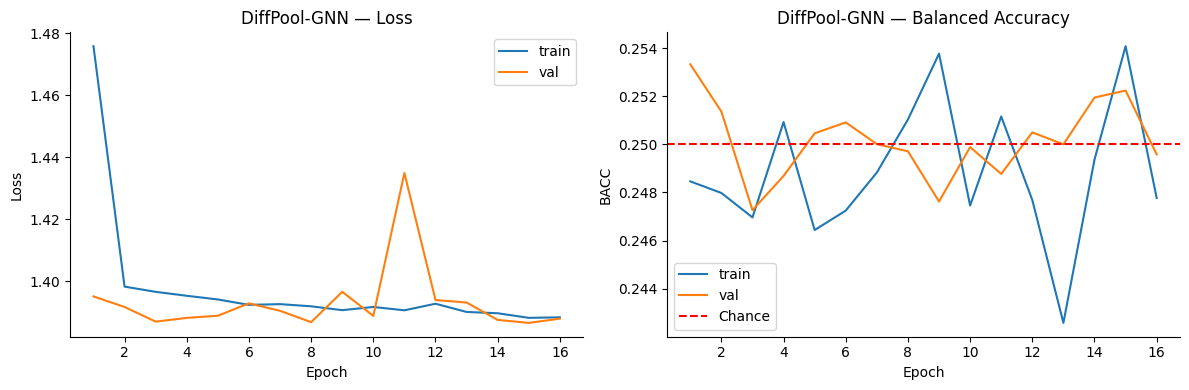

In [16]:
# ── DiffPool-GNN — Curva di training ───────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_B['epoch'], history_B['tr_loss'], label='train')
ax1.plot(history_B['epoch'], history_B['vl_loss'], label='val')
ax1.set(title='DiffPool-GNN — Loss', xlabel='Epoch', ylabel='Loss')
ax1.legend(); ax1.spines[['top','right']].set_visible(False)
ax2.plot(history_B['epoch'], history_B['tr_bacc'], label='train')
ax2.plot(history_B['epoch'], history_B['vl_bacc'], label='val')
ax2.axhline(0.25, color='red', linestyle='--', label='Chance')
ax2.set(title='DiffPool-GNN — Balanced Accuracy', xlabel='Epoch', ylabel='BACC')
ax2.legend(); ax2.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eeg10_diffpool_training.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── DiffPool-GNN — Pulizia GPU ─────────────────────────────────────────────
del model_B, ds_train_B, ds_val_B
import gc; gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated, {torch.cuda.memory_reserved()/1e9:.2f} GB reserved")


---
## Modello C — CBraMod (Foundation Model, Fine-Tuning)

**Paper**: Tang et al., *"CBraMod: A Criss-Cross Brain Foundation Model for EEG Decoding"*,
ICLR 2025. [[arxiv]](https://arxiv.org/abs/2412.07236)

**Idea chiave**: CBraMod è un **modello fondazionale pre-addestrato** su un corpus
enorme di segnali EEG (decine di dataset, migliaia di soggetti) attraverso
masked autoencoding su patch EEG. Il fine-tuning usa il suo encoder come
feature extractor frozen + una testa di classificazione addestrabile.

**Perché è diverso**: affronta il problema cross-subject direttamente —
il pre-training su diversi soggetti ha già "visto" molta variabilità inter-soggetto
e ha imparato feature invarianti rispetto alla firma del soggetto.

**Architettura interna**: transformer criss-cross con:
- Attenzione spaziale (tra canali)
- Attenzione temporale (tra patch temporali)
Alternate in layers, usando positional encoding asimmetrico per adattarsi
a EEG con formati diversi (numero canali variabile).

**Setup fine-tuning**: encoder congelato (frozen) per le prime 20 epoche,
poi unfreezing parziale per le ultime 20.

In [17]:
# ── CBraMod — Caricamento modello ───────────────────────────────────────────
try:
    from braindecode.models import CBraMod
    CBRAMOD_OK = True
    print('CBraMod importato da Braindecode.')
except ImportError as e:
    CBRAMOD_OK = False
    print(f'CBraMod non disponibile: {e}')
    print('Verifica: pip install braindecode>=1.3.2 o aggiorna il package.')

if CBRAMOD_OK:
    # Istanzia CBraMod con i parametri corretti per il nostro dataset
    # n_times=384, n_chans=59, n_outputs=N_CLASSES
    # Controlla la firma della classe con: help(CBraMod) o CBraMod?
    try:
        model_C = CBraMod(
            n_times=N_TIMES,
            n_channels=N_CHANS,
            n_outputs=N_CLASSES,
            sfreq=256,
        ).to(DEVICE)
    except TypeError:
        # Fallback: prova parametri alternativi
        try:
            model_C = CBraMod(
                n_outputs=N_CLASSES,
                n_chans=N_CHANS,
                input_window_seconds=N_TIMES / 256.0,
                sfreq=256,
            ).to(DEVICE)
        except Exception as e2:
            print(f'Errore istanziazione CBraMod: {e2}')
            print('Esegui help(CBraMod) per vedere i parametri corretti.')
            CBRAMOD_OK = False

if CBRAMOD_OK:
    _x = torch.randn(4, N_CHANS, N_TIMES).to(DEVICE)
    with torch.no_grad():
        out = model_C(_x)
    print(f'CBraMod output shape: {out.shape}')  # atteso (4, N_CLASSES)
    n_params = sum(p.numel() for p in model_C.parameters())
    n_train  = sum(p.numel() for p in model_C.parameters() if p.requires_grad)
    print(f'Parametri totali: {n_params:,} | trainable: {n_train:,}')
    del _x

CBraMod non disponibile: cannot import name 'CBraMod' from 'braindecode.models' (/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/braindecode/models/__init__.py)
Verifica: pip install braindecode>=1.3.2 o aggiorna il package.


In [ ]:
# ── CBraMod — Fine-tuning ───────────────────────────────────────────────────
if CBRAMOD_OK:
    for name, param in model_C.named_parameters():
        if 'final_layer' not in name and 'fc' not in name.lower() and 'head' not in name.lower():
            param.requires_grad = False

    n_trainable = sum(p.numel() for p in model_C.parameters() if p.requires_grad)
    print(f'Fase 1 — trainable params: {n_trainable:,} (solo testa)')

    ds_train_C = EEGRawDataset(train_data)
    ds_val_C   = EEGRawDataset(val_data)

    best_bacc_C, history_C, ckpt_C = train_model(model_C, ds_train_C, ds_val_C, 'cbramod')
    RESULTS['CBraMod'] = best_bacc_C
    history_C.to_csv(EEG10_INTERIM / 'eeg10_cbramod_history.csv', index=False)
    print(f'\n[CBraMod] Best val_bacc: {best_bacc_C:.4f}')
else:
    print('[SKIP] CBraMod non disponibile.')
    RESULTS['CBraMod'] = None

In [19]:
# ── CBraMod — Curva di training ─────────────────────────────────────────────
if CBRAMOD_OK and 'history_C' in dir():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history_C['epoch'], history_C['tr_loss'], label='train')
    ax1.plot(history_C['epoch'], history_C['vl_loss'], label='val')
    ax1.set(title='CBraMod — Loss', xlabel='Epoch', ylabel='Loss')
    ax1.legend(); ax1.spines[['top','right']].set_visible(False)
    ax2.plot(history_C['epoch'], history_C['tr_bacc'], label='train')
    ax2.plot(history_C['epoch'], history_C['vl_bacc'], label='val')
    ax2.axhline(0.25, color='red', linestyle='--', label='Chance')
    ax2.set(title='CBraMod — Balanced Accuracy', xlabel='Epoch', ylabel='BACC')
    ax2.legend(); ax2.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'eeg10_cbramod_training.png', dpi=120, bbox_inches='tight')
    plt.show()

In [ ]:
# ── CBraMod — Pulizia GPU ──────────────────────────────────────────────────
if CBRAMOD_OK:
    del model_C, ds_train_C, ds_val_C
import gc; gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated, {torch.cuda.memory_reserved()/1e9:.2f} GB reserved")


---
## Modello D — AT-DGNN (Adaptive Temporal + Dynamic Graph)

**Paper ispirazione**: Liu et al., *"MEEG and AT-DGNN: Advancing EEG Emotion Recognition
with Music and Graph Learning"*, IEEE BIBM 2024.
[[GitHub]](https://github.com/xmh1011/AT-DGNN)

**Idea chiave**: due moduli separati che cooperano:
1. **Temporal Attention Learner** — impara quali segmenti temporali dell'epoca
   sono più informativi per la classificazione
2. **Dynamic GNN** — costruisce il grafo adattativamente dai features attenzionati,
   invece di usare correlazioni PCC pre-calcolate

```
Input (B, 59, 384)
    ↓  Divide in W finestre temporali
(B, 59, W, T/W)
    ↓  Temporal Attention: pesa le finestre
(B, 59, F_temp)  ← features ponderate
    ↓  Dynamic adjacency: A = sigmoid(MLP(X) @ MLP(X).T)
    ↓  GAT layers con adiacenza dinamica
(B, 59, F_gnn)
    ↓  Global mean + FC
(B, 4)
```

**Perché potrebbe funzionare**: separa il problema temporale (quale finestra
del segnale è più informativa) da quello spaziale (quali elettrodi interagiscono).
La finestra più discriminativa potrebbe non essere quella media sull'intera epoca.

In [20]:
# ── AT-DGNN — Architettura ──────────────────────────────────────────────────

class TemporalAttentionLearner(nn.Module):
    """Divide il segnale in W finestre, impara pesi di attenzione per finestra."""
    def __init__(self, n_times, n_windows=8, n_chans=59, out_features=64):
        super().__init__()
        self.n_windows = n_windows
        win_size = n_times // n_windows

        # Conv per estrarre features da ogni finestra
        self.win_conv = nn.Sequential(
            nn.Conv1d(1, out_features, kernel_size=min(25, win_size//2+1), padding=min(25, win_size//2+1)//2),
            nn.BatchNorm1d(out_features), nn.ELU(),
            nn.AdaptiveAvgPool1d(1),
        )
        # Rete di attenzione: (n_windows, out_features) → (n_windows, 1)
        self.attn_net = nn.Sequential(
            nn.Linear(out_features, 32), nn.Tanh(),
            nn.Linear(32, 1)
        )
        self.out_features = out_features

    def forward(self, x):
        # x: (B, 59, T)
        B, C, T = x.shape
        win_size = T // self.n_windows
        # Split in finestre: (B, 59, W, win_size)
        x_win = x[:, :, :win_size * self.n_windows].reshape(B, C, self.n_windows, win_size)

        # Estrai features per ogni canale e finestra
        feats = []
        for w in range(self.n_windows):
            # (B, C, win_size) → (B*C, 1, win_size) → conv → (B*C, out, 1)
            xw = x_win[:, :, w, :].reshape(B * C, 1, win_size)
            fw = self.win_conv(xw).squeeze(-1)    # (B*C, out_features)
            feats.append(fw.reshape(B, C, self.out_features))
        feats = torch.stack(feats, dim=2)         # (B, C, W, out_features)

        # Attenzione: media su canali, poi pesi finestre
        feats_mean = feats.mean(dim=1)             # (B, W, out_features)
        attn_w = F.softmax(self.attn_net(feats_mean), dim=1)  # (B, W, 1)
        out = (feats * attn_w.unsqueeze(1)).sum(dim=2)         # (B, C, out_features)
        return out  # (B, 59, out_features)


class ATDGNN(nn.Module):
    def __init__(self, n_classes, n_chans=59, n_times=384,
                 n_windows=8, node_feat=64, gnn_layers=2):
        super().__init__()

        # 1. Temporal attention
        self.temporal_attn = TemporalAttentionLearner(
            n_times, n_windows=n_windows, n_chans=n_chans, out_features=node_feat)

        # 2. Adjacency MLP
        self.adj_mlp = nn.Sequential(
            nn.Linear(node_feat, node_feat // 2),
            nn.ELU(),
            nn.Linear(node_feat // 2, node_feat // 2)
        )

        # 3. GNN layers (dense GCN con adiacenza dinamica)
        gnn_dims = [node_feat] + [node_feat * 2] * gnn_layers
        self.gnn_layers = nn.ModuleList([
            DenseGCN(gnn_dims[i], gnn_dims[i+1])
            for i in range(gnn_layers)
        ])

        # 4. Classificatore
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_chans * gnn_dims[-1], 256),
            nn.ELU(), nn.Dropout(0.5),
            nn.Linear(256, n_classes)
        )

    def _dynamic_adj(self, x):
        # x: (B, N, F) → A: (B, N, N)
        q = self.adj_mlp(x)
        A = torch.bmm(q, q.transpose(1, 2)) / (q.size(-1) ** 0.5)
        return torch.sigmoid(A)

    def forward(self, x):
        # x: (B, 59, T)
        H = self.temporal_attn(x)          # (B, 59, node_feat)
        A = self._dynamic_adj(H)            # (B, 59, 59)
        for layer in self.gnn_layers:
            H = layer(H, A)
        return self.classifier(H)


_m = ATDGNN(N_CLASSES).to(DEVICE)
_x = torch.randn(4, N_CHANS, N_TIMES).to(DEVICE)
print(f'AT-DGNN output: {_m(_x).shape}')
print(f'Parametri: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')
del _m, _x

AT-DGNN output: torch.Size([4, 4])
Parametri: 1,966,981


In [ ]:
# ── AT-DGNN — Training ──────────────────────────────────────────────────────
model_D = ATDGNN(N_CLASSES).to(DEVICE)
ds_train_D = EEGRawDataset(train_data)
ds_val_D   = EEGRawDataset(val_data)

best_bacc_D, history_D, ckpt_D = train_model(model_D, ds_train_D, ds_val_D, 'atdgnn')
RESULTS['AT-DGNN'] = best_bacc_D
history_D.to_csv(EEG10_INTERIM / 'eeg10_atdgnn_history.csv', index=False)
print(f'\n[AT-DGNN] Best val_bacc: {best_bacc_D:.4f}')

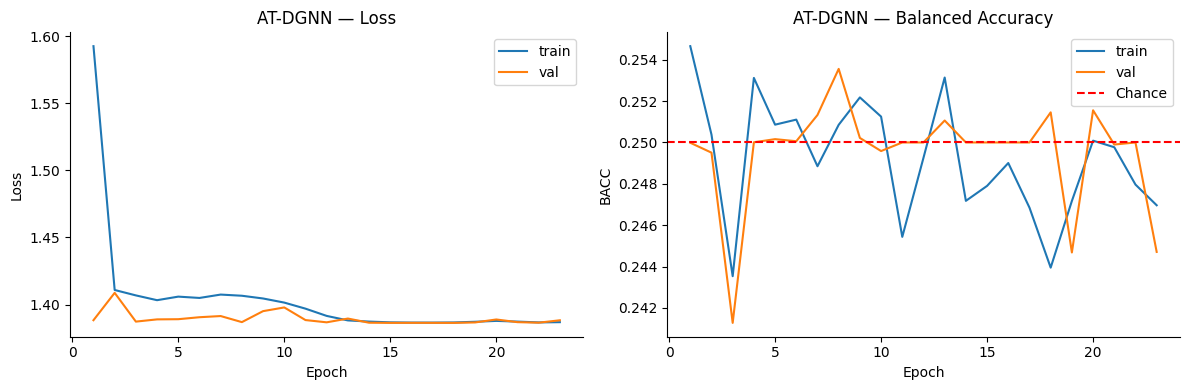

In [22]:
# ── AT-DGNN — Curva di training ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_D['epoch'], history_D['tr_loss'], label='train')
ax1.plot(history_D['epoch'], history_D['vl_loss'], label='val')
ax1.set(title='AT-DGNN — Loss', xlabel='Epoch', ylabel='Loss')
ax1.legend(); ax1.spines[['top','right']].set_visible(False)
ax2.plot(history_D['epoch'], history_D['tr_bacc'], label='train')
ax2.plot(history_D['epoch'], history_D['vl_bacc'], label='val')
ax2.axhline(0.25, color='red', linestyle='--', label='Chance')
ax2.set(title='AT-DGNN — Balanced Accuracy', xlabel='Epoch', ylabel='BACC')
ax2.legend(); ax2.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eeg10_atdgnn_training.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── AT-DGNN — Pulizia GPU ──────────────────────────────────────────────────
del model_D, ds_train_D, ds_val_D
import gc; gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB allocated, {torch.cuda.memory_reserved()/1e9:.2f} GB reserved")


---
## Riepilogo — Confronto Modelli

In [ ]:
# ── Riepilogo finale ────────────────────────────────────────────────────────
# Aggiunge baseline da EEG_08 (ChebGCN PCC/3L) per confronto
RESULTS_FULL = {
    'ChebGCN (EEG_08 baseline)': 0.2607,
    **{k: v for k, v in RESULTS.items() if v is not None}
}

df_res = pd.DataFrame([
    {'Modello': k, 'val_bacc': v} for k, v in RESULTS_FULL.items()
]).sort_values('val_bacc', ascending=False)

print('\n=== RISULTATI EEG_10 ===')
print(df_res.to_string(index=False))
df_res.to_csv(EEG10_INTERIM / 'eeg10_results_summary.csv', index=False)

# Plot comparativo
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#cccccc'] + ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = ax.barh(df_res['Modello'], df_res['val_bacc'],
               color=colors[:len(df_res)], alpha=0.85, edgecolor='white')
ax.axvline(0.25, color='red', linestyle='--', linewidth=1.5, label='Chance 25%')
for bar, val in zip(bars, df_res['val_bacc']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
ax.set(xlabel='Val Balanced Accuracy', title='EEG_10 — Confronto Modelli Advanced GNN\n(4 classi semantiche, cross-subject)')
ax.legend()
ax.spines[['top','right']].set_visible(False)
ax.set_xlim(0.22, min(ax.get_xlim()[1], 0.55))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eeg10_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Salvato: figures/eeg10_comparison.png')